corresponding to archive-46

In [1]:
%pip install pandas

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ------- -------------------------------- 2.1/11.4 MB 10.7 MB/s eta 0:00:01
   ------------ --------------------------- 3.4/11.4 MB 10.1 MB/s eta 0:00:01
   ------------------- -------------------- 5.5/11.4 MB 8.8 MB/s eta 0:00:01
   -------------------------- ------------- 7.6/11.4 MB 9.0 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.4 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.4 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.4 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.4 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 11.4/11.4 MB 6.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math
import pandas as pd

item:{'task': 'AdultIncomeFeatureSelection', 'AF': '0.95', 'algorithm': 'ILP', 'budget': 10.0, 'heuristic': 'ub0', 'sorting': 'd', 'node count': 120, 'open list count': 120, 'computational time': 1546.5430948734283, 'f(S)': np.float64(8.56897596445756)}
item:{'task': 'AdultIncomeFeatureSelection', 'AF': '0.95', 'algorithm': 'ILP', 'budget': 11.0, 'heuristic': 'ub0', 'sorting': 'd', 'node count': 138, 'open list count': 138, 'computational time': 2253.866476535797, 'f(S)': np.float64(8.735331287791945)}
item:{'task': 'AdultIncomeFeatureSelection', 'AF': '0.95', 'algorithm': 'ILP', 'budget': 12.0, 'heuristic': 'ub0', 'sorting': 'd', 'node count': 227, 'open list count': 227, 'computational time': 3947.3050758838654, 'f(S)': np.float64(8.922616536876916)}
item:{'task': 'AdultIncomeFeatureSelection', 'AF': '0.95', 'algorithm': 'ILP', 'budget': 6.0, 'heuristic': 'ub0', 'sorting': 'd', 'node count': 36, 'open list count': 36, 'computational time': 21.87433671951294, 'f(S)': np.float64(7.2065

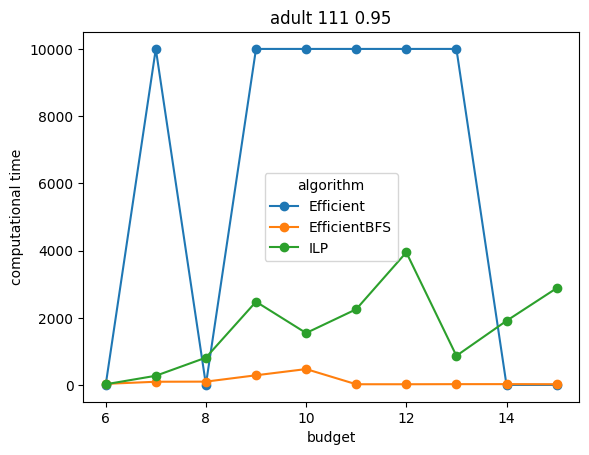

In [ ]:
# task
# AF
# algorithm
# budget
# ub
# node count
# time

def get_data(source_dir: str, target_af = 1.0):
    """
    kv_data has the following keys: 
    - 'S'
    - 'f(S)'
    - 'c(S)'
    - 'Lambda'
    - 'AF'
    """
    task_dict = {
        "facebook": "FacebookGraphCoverage",
        "youtube" : "YoutubeCoverage",
        "caltech": "CalTechMaximization",
        "adult": "AdultIncomeFeatureSelection"
    }

    res = []
    for name in os.listdir(source_dir):
        if not os.path.isdir(os.path.join(source_dir, name)):
            algo, ub, d, budget, af, task = name.strip()[:-5].split('-')

            if float(af) == target_af:
                if algo=='EfficientBFS' and ub == 'ub0':
                    continue
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)

                open_list_count = 0
                if 'open_list_count' in kv_data.keys():
                    open_list_count = kv_data['open_list_count']

                res.append(
                    {
                        'task': task,
                        'AF': af,
                        'algorithm': algo,
                        'budget': float(eval(budget)),
                        'heuristic': ub,
                        'sorting': d,
                        'node count': kv_data['node_count'],
                        'open list count': open_list_count, 
                        'computational time': kv_data['time'],
                        'f(S)': kv_data['f(S)']
                    }
                )

    return res


task = 'adult'
n = 111
target_af = 0.95
seed = 0
result_dir = "./result_92"
archive_dir = "../result/archive-92"

algs = [
     'EfficientBFS', 'Efficient', 'ILP', 
]

res = []

source_dir = os.path.join(archive_dir, f"{task}", f"{n}", f"{seed}")
res  = get_data(source_dir=source_dir, target_af=target_af)

for item in res:
    if item['algorithm'] == 'ILP':
        print(f"item:{item}")

df = pd.DataFrame(
    res
)


filtered_df = df[df['algorithm'].isin(algs)]
# condition1 = ((filtered_df['algorithm'] == 'BFSTC') |  (filtered_df['algorithm'] == 'ILP')) & (filtered_df['heuristic'] == 'ub0')
# condition2 = (filtered_df['algorithm'] != 'BFSTC') & (filtered_df['algorithm'] != 'ILP')

condition1 = ((filtered_df['algorithm'] == 'BFSTC') ) & (filtered_df['heuristic'] == 'ub0')
condition2 = (filtered_df['algorithm'] != 'BFSTC') 

filtered_df = filtered_df[condition1 | condition2]
filtered_df = filtered_df[filtered_df['budget'].isin(range(6, 16, 1))]


filtered_df = filtered_df.sort_values(by=['budget', 'algorithm'], ascending=True)

html_path = os.path.join(result_dir, f"{task}_{n}_{seed}_{target_af}.html")
filtered_df.to_html(html_path)

# This prints every row that has a twin elsewhere in the data
duplicates = filtered_df[filtered_df.duplicated(subset=['algorithm', 'budget'], keep=False)]

print(f"Found {len(duplicates)} duplicate rows:")
print(duplicates.sort_values(by=list(filtered_df.columns))) # Sorting helps you see them side-by-side

pivot_df = filtered_df.pivot(index='budget', columns='algorithm', values='computational time')

# Plotting all columns (algorithms) on the same axes
pivot_df.plot(kind='line', marker='o')

plt.ylabel('computational time')
plt.title(f'{task} {n} {target_af}')
plt.savefig(os.path.join(result_dir, f"{task}_{n}_{target_af}.jpg"), format='jpg', bbox_inches='tight')

youtube: 
ub:ub1-, mean:0.9186720956994848
ub:ub1ma-, mean:0.9186720956994848
ub:ub7-, mean:0.9582867090598242
ub:ub7ma-, mean:0.9582867090598242
ub:ub1si, mean:0.9186720956994848
ub:ub1msi, mean:0.9186720956994848
ub:ub7si, mean:0.9582867090598242
ub:ub7msi, mean:0.9582867090598242
ub:ub1, mean:0.9206231187392625
ub:ub1ma, mean:0.9206231187392625
ub:ub7, mean:0.9581183264717915
ub:ub7ma, mean:0.9582867090598243
ub:ub11, mean:0.9611532377303219
ub:ub11m, mean:0.9611532377303219

ub:ub7u, mean:0.9611532377303217
ub:ub7mu, mean:0.9611532377303219

ub:ub1-, mean:2.1998542857170107
ub:ub1ma-, mean:2.1772330716678074
ub:ub7-, mean:2.1990658262797766
ub:ub7ma-, mean:2.204027172497341
ub:ub1si, mean:2.3446680242674693
ub:ub1msi, mean:3.3019391758101326
ub:ub7si, mean:2.359261659894671
ub:ub7msi, mean:3.308534472329276
ub:ub1, mean:3.646958782332284
ub:ub1ma, mean:5.4384882543768205
ub:ub7, mean:3.994540059055601
ub:ub7ma, mean:5.588278126205717
ub:ub11, mean:4.990155854906354
ub:ub11m, mean:8.678127495561327
ub:ub7u, mean:92.12287601402828
ub:ub7mu, mean:88.15307073865618
facebook:
ub:ub1-, mean:0.7296328553065745
ub:ub1ma-, mean:0.7296328553065745
ub:ub7-, mean:0.9033035542840437
ub:ub7ma-, mean:0.9033035542840437
ub:ub1si, mean:0.817562309960068
ub:ub1msi, mean:0.8162818669554469
ub:ub7si, mean:0.9033035542840437
ub:ub7msi, mean:0.9033035542840437
ub:ub1, mean:0.7879491300447704
ub:ub1ma, mean:0.7879491300447704
ub:ub7, mean:0.9048584380636079
ub:ub7ma, mean:0.9048584380636079
ub:ub11, mean:0.9369806875200489
ub:ub11m, mean:0.9369806875200489
ub:ub7u, mean:0.9369810788249513
ub:ub7mu, mean:0.9369810788249513

ub:ub1-, mean:10.156772418703351
ub:ub1ma-, mean:10.178715040002551
ub:ub7-, mean:11.450547438689641
ub:ub7ma-, mean:11.441761809757777
ub:ub1si, mean:10.567305464940528
ub:ub1msi, mean:12.422250057629176
ub:ub7si, mean:11.43991986649377
ub:ub7msi, mean:13.513164984158108
ub:ub1, mean:17.080751057182038
ub:ub1ma, mean:22.30761598621096
ub:ub7, mean:19.694336768559047
ub:ub7ma, mean:25.609976363522666
ub:ub11, mean:22.48161468744278
ub:ub11m, mean:32.53470688956124
ub:ub7u, mean:224.22911675146648
ub:ub7mu, mean:218.29923068319047
adult:
ub:ub1-, mean:0.3663953430082084
ub:ub1ma-, mean:0.3663953430082084
ub:ub7-, mean:0.9321324903408477
ub:ub7ma-, mean:0.9321324903408477
ub:ub1si, mean:0.8991680534963996
ub:ub1msi, mean:0.8993155922424952
ub:ub7si, mean:0.9324057888705072
ub:ub7msi, mean:0.9324057888705072
ub:ub1, mean:0.92196520698924
ub:ub1ma, mean:0.92196520698924
ub:ub7, mean:0.9464274722566821
ub:ub7ma, mean:0.9464274722566821
ub:ub11, mean:0.9279227659135875
ub:ub11m, mean:0.9279227659135875
ub:ub7u, mean:0.9472846774763409
ub:ub7mu, mean:0.9472846774763409

ub:ub1-, mean:3.409646825449807
ub:ub1ma-, mean:3.4032790286200387
ub:ub7-, mean:5.061992425577981
ub:ub7ma-, mean:5.300253184863499
ub:ub1si, mean:3.986990522827421
ub:ub1msi, mean:4.348523508480617
ub:ub7si, mean:5.319288135256086
ub:ub7msi, mean:6.222097857339041
ub:ub1, mean:7.800832927567618
ub:ub1ma, mean:10.876680651732853
ub:ub7, mean:19.75093980721065
ub:ub7ma, mean:31.90761156456811
ub:ub11, mean:7.363404408182417
ub:ub11m, mean:10.999628932816641
ub:ub7u, mean:16.257781765801568
ub:ub7mu, mean:19.5762131857872
caltech:
ub:ub1-, mean:0.8996628353502881
ub:ub1ma-, mean:0.8996628353502881
ub:ub7-, mean:0.9121758810121805
ub:ub7ma-, mean:0.9121758810121805
ub:ub1si, mean:0.8964319387728119
ub:ub1msi, mean:0.9540251682608832
ub:ub7si, mean:0.9087300028929765
ub:ub7msi, mean:0.9556039658533528
ub:ub1, mean:0.9001632635253197
ub:ub1ma, mean:0.9651514093870396
ub:ub7, mean:0.9119099142943798
ub:ub7ma, mean:0.9652188800235331
ub:ub11, mean:0.9299018118989292
ub:ub11m, mean:0.9665976412592359
ub:ub7u, mean:0.9299018118989292
ub:ub7mu, mean:0.9665976412592356

ub:ub1-, mean:3.0233540766579763
ub:ub1ma-, mean:3.016016568456377
ub:ub7-, mean:3.05027845961707
ub:ub7ma-, mean:3.1166447084290643
ub:ub1si, mean:3.082464378220694
ub:ub1msi, mean:3.27660879782268
ub:ub7si, mean:3.118381526470184
ub:ub7msi, mean:3.255154275553567
ub:ub1, mean:6.022671917506627
ub:ub1ma, mean:6.0596006648881096
ub:ub7, mean:3.8768883432660783
ub:ub7ma, mean:7.8252654807908195
ub:ub11, mean:5.658287454673222
ub:ub11m, mean:6.240117999485561
ub:ub7u, mean:7.533744722775051
ub:ub7mu, mean:8.605766882215228

adult:
ub:ub7ma-, mean:5.172754121746336
ub:ub7ma, mean:15.610951846803937
ub:ub11, mean:7.523969499758311
ub:ub11m, mean:10.74899403166771
caltech:
ub:ub7ma-, mean:3.1488801897253307
ub:ub7ma, mean:5.536494000775473
ub:ub11, mean:5.740553117990494
ub:ub11m, mean:6.040017505884171
youtube:
ub:ub7ma-, mean:3.4927254092352733
ub:ub7ma, mean:7.555086037312235
ub:ub11, mean:7.906369193690164
ub:ub11m, mean:11.793283801862172
facebook:
ub:ub7ma-, mean:10.558673332418714
ub:ub7ma, mean:22.968542100204303
ub:ub11, mean:21.748473752771105
ub:ub11m, mean:31.993870065552848